In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal


    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []

        row, col = state

        for action, (dr, dc) in MOVES.items():
            new_row, new_col = row + dr, col + dc

            if self.in_bounds((new_row, new_col)) and self.is_free((new_row, new_col)):
                legal_actions.append(action)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
      row, col = state
      dr, dc = MOVES[action]
      return (row + dr, col + dc)


    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],) -> float:
        return 1



In [6]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [7]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [8]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

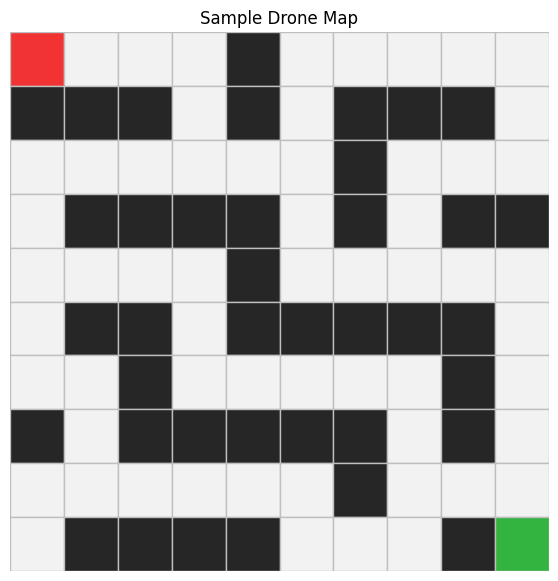

In [9]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [10]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
      state = node.state
      for action in problem.actions(node.state):
        s_prime = problem.result(node.state, action)
        cost = node.path_cost + problem.action_cost(node.state, action, s_prime)
        yield Node(state=s_prime, parent=node, action=action, path_cost=cost)



    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [11]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        node = Node(state=problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(algorithm, "SUCCESS", node, 0, 0)
        frontier = deque([node])
        reached = {problem.initial_state()}
        max_frontier_size = 1
        nodes_expanded = 0

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
              if problem.is_goal(child.state):
                return SearchResult(algorithm, "SUCCESS", child, nodes_expanded, max_frontier_size)


              if child.state not in reached:
                reached.add(child.state)
                frontier.append(child)


              if len(frontier) > max_frontier_size:
                  max_frontier_size = len(frontier)

        return SearchResult(algorithm, "FAILURE", None, nodes_expanded, max_frontier_size)



In [12]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        node = Node(state=problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(algorithm, "SUCCESS", node, 0, 0)

        frontier = [node]
        reached = {problem.initial_state()}
        max_frontier_size = 1
        nodes_expanded = 0

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            for child in self.expand(problem, node):
              if problem.is_goal(child.state):
                return SearchResult(algorithm, "SUCCESS", child, nodes_expanded, max_frontier_size)
              if child.state not in reached:
                reached.add(child.state)
                frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(algorithm, "FAILURE", None, nodes_expanded, max_frontier_size)




In [13]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:


        if problem.is_goal(node.state):
          return (node, "success")

        elif node.depth >= limit:
          return (None, "cutoff")


        metrics["nodes_expanded"] += 1

        cutoff_occurred = False

        for child in self.expand(problem, node):
          if state_is_on_path(node, child.state):
            continue

          metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)

          result, status = self._recursive_dls(
              problem=problem,
              node=child,
              limit=limit,
              metrics=metrics,
              current_stack_size=current_stack_size + 1,
            )

          if status == "success":
              return (result, status)

          elif status == "cutoff":
              cutoff_occurred = True

        if cutoff_occurred:
          return (None, "cutoff")


        return (None, "failure")




In [14]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        dls = DepthLimitedSearch()

        iteration_log = []
        total_nodes_expanded = 0
        max_stack_size = 0

        for depth in range(max_depth + 1):

            result = dls.search(problem, limit=depth)

            total_nodes_expanded += result.nodes_expanded
            max_stack_size = max(
                max_stack_size,
                result.max_frontier_size
            )

            iteration_log.append(
                {"depth": depth, "nodes_expanded": result.nodes_expanded, "max_stack_size": result.max_frontier_size,}
            )

            if result.status == "success":
                return SearchResult( algorithm="IDS", status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    iterations=iteration_log,
                    limit=depth,
                )

            if result.status == "failure":
                return SearchResult(
                    algorithm="IDS",
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    iterations=iteration_log,
                    limit=depth,
                )

        return SearchResult(
            algorithm="IDS",
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            iterations=iteration_log,
            limit=max_depth,
        )


In [15]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,SUCCESS,NaN,18.0,18.0,50,5,0
1,DFS,SUCCESS,NaN,18.0,18.0,18,4,0
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


In [16]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=60),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,SUCCESS,NaN,18,18,50,5,0
1,DFS,SUCCESS,NaN,18,18,18,4,0
2,DLS,success,60.0,26,26,76,47,0
3,IDS,success,18.0,18,18,356,19,0


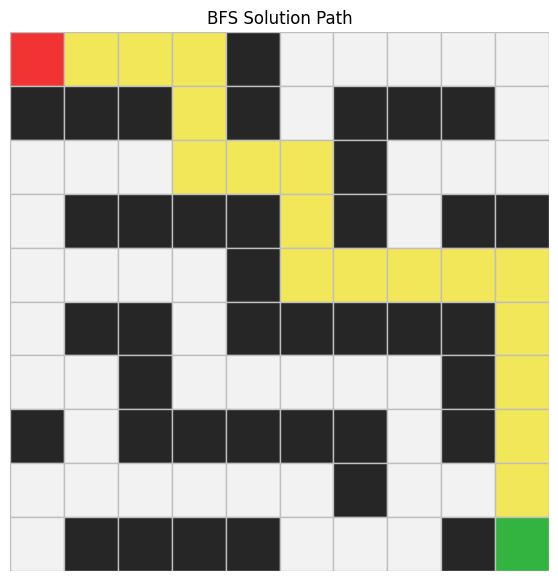

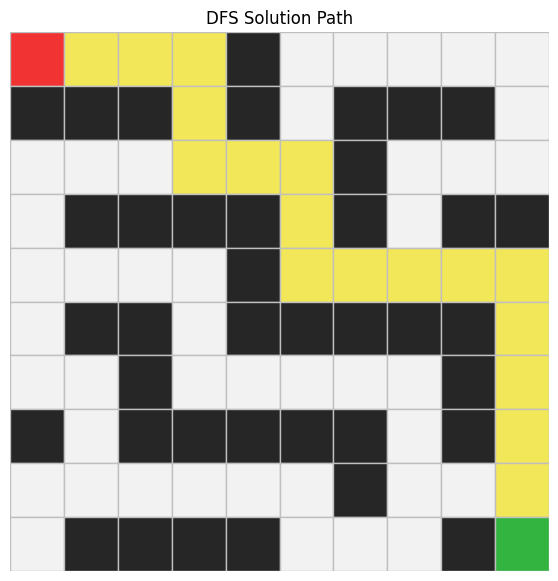

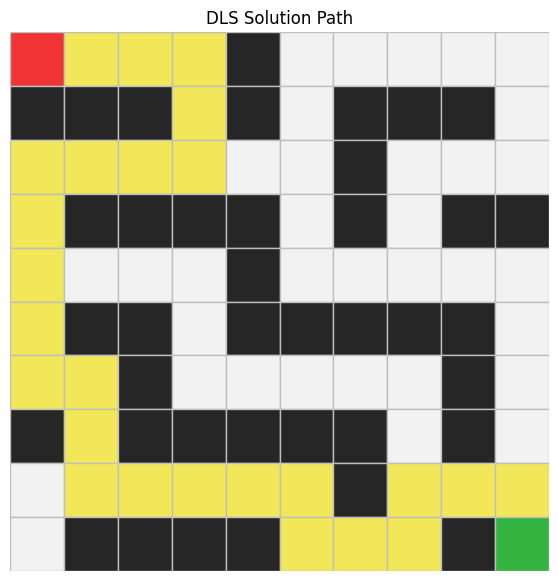

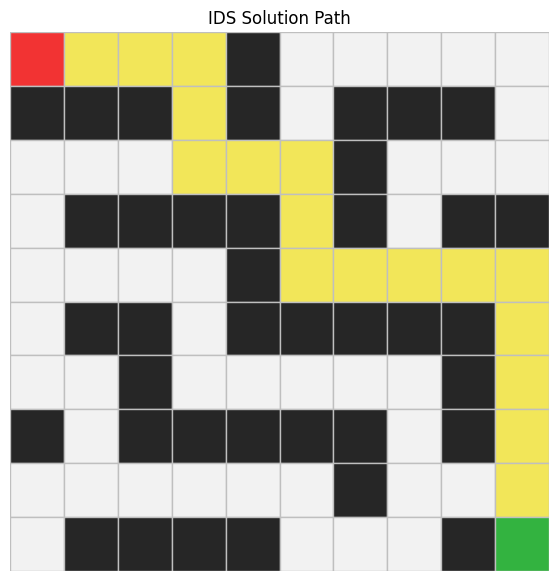

In [17]:
bfs_result = results[0]
dfs_result = results[1]
dls_result = results[2]
ids_result = results[3]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dls_result.path,
    title="DLS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=ids_result.path,
    title="IDS Solution Path",
)

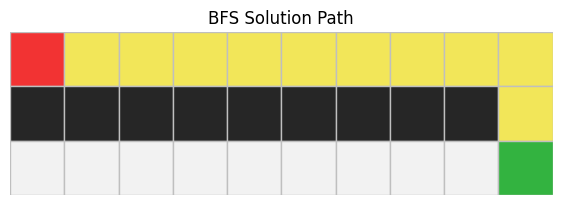

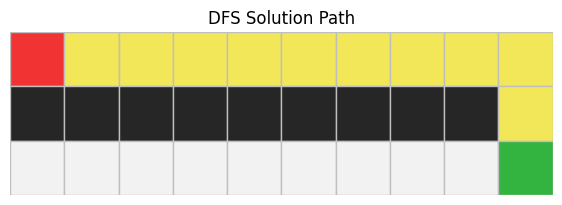

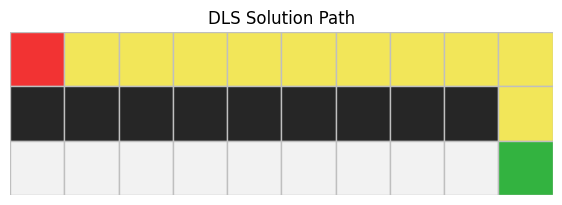

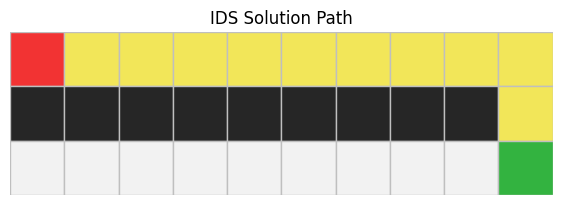

In [18]:
custom_grid_1 = [
    [0,0,0,0,0,0,0,0,0,0],
    [1,1,1,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0]
]

custom_start_1 = (0,0)
custom_goal_1 = (2,9)




custom_problem_1 = GridProblem(
    custom_grid_1,
    custom_start_1,
    custom_goal_1
)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40)

]



show_results(custom_results_1)

bfs_result = custom_results_1[0]
dfs_result = custom_results_1[1]
dls_result = custom_results_1[2]
ids_result = custom_results_1[3]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=dfs_result.path,
    title="DFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=dls_result.path,
    title="DLS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=ids_result.path,
    title="IDS Solution Path",
)



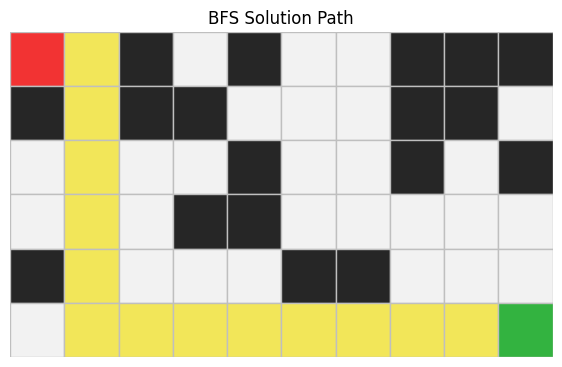

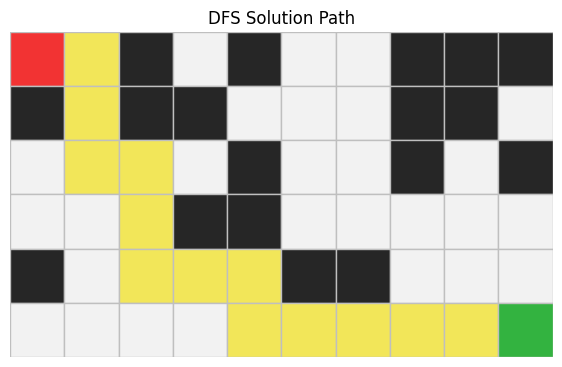

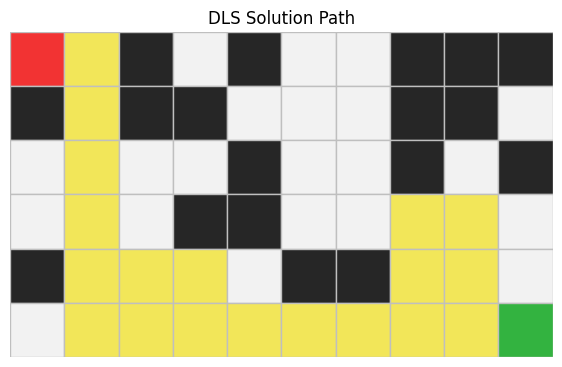

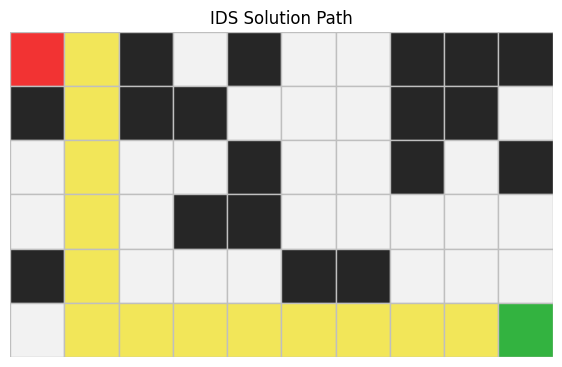

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,SUCCESS,NaN,14,14,24,5,0
1,DFS,SUCCESS,NaN,14,14,15,7,0
2,DLS,success,20.0,20,20,32,21,0
3,IDS,success,14.0,14,14,970,15,0


In [19]:
custom_grid_2 = [
    [0,0,1,0,1,0,0,1,1,1],
    [1,0,1,1,0,0,0,1,1,0],
    [0,0,0,0,1,0,0,1,0,1],
    [0,0,0,1,1,0,0,0,0,0],
    [1,0,0,0,0,1,1,0,0,0],
    [0,0,0,0,0,0,0,0,0,0]
]

custom_start_2 = (0,0)
custom_goal_2 = (5,9)




custom_problem_2 = GridProblem(
    custom_grid_2,
    custom_start_2,
    custom_goal_2
)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40)

]

show_results(custom_results_2)

bfs_result = custom_results_2[0]
dfs_result = custom_results_2[1]
dls_result = custom_results_2[2]
ids_result = custom_results_2[3]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=bfs_result.path,
    title="BFS Solution Path",
)




plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=dfs_result.path,
    title="DFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=dls_result.path,
    title="DLS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=ids_result.path,
    title="IDS Solution Path",
)

show_results(custom_results_2)



15.1 Problem Formulation

What is a state in this lab?

*  The main cost is repeated work because nodes near the root are expanded multiple times during successive depth-limited searches.


In this lab, a state is the current position of the drone on the grid which is represented as a row-column coordinate.

What is an action?

* An action is a legal movement that the drone can make within
the state space and from its current position. (UP, DOWN, LEFT, RIGHT)

What does the result function do?

* The result function shows the next state after the action has been performed from the initial state.

Why is it useful to separate the problem definition from the search algorithm?

* It is useful to do this because it makes the code reusable for different problems as long as they are implementing the same methods and techniques.


15.2 BFS

Why does BFS use a FIFO queue?

* It uses the FIFO queue because it explores the states in order of their discovery, and nodes at the shallower depth first before moving deeper into the deeper nodes.

Why does BFS find the shortest path in terms of number of steps on the unweighted grid?

* This is because, it expands all nodes on the shallower level before moving to deeper levels, meaning that if it finds the goal at a particular level, it will end, and that path would be the shortest path to the goal state.


What role does the reached set play in BFS?

* It prevents revisiting states that have already been explored to avoid unnecessary work or infinite cycles.


15.3 DFS

Why does DFS use a stack?

* It uses stack because it expands the most recently discovered node first and deeply, before backtracking.

Is DFS guaranteed to find the shortest path? Explain.

* No. It may find a solution that is longer to the goal because it fully goes through one branch first before exploring others.

Under what conditions can DFS use less memory than BFS?

* The DFS uses less memory because it stores the expanded node and the few unexpanded ones, while the BFS stores all nodes which have been expanded.

Under what conditions can DFS perform badly?

* DFS performs badly when the paths are deep because it may end up spending a lot of time exploring a path which would not yield meaningful results.

15.4 DLS

What happens when the depth limit is too small?
* When depth limit is too small, search will not reach the goal and return cutoff.

What is the meaning of "cutoff"?

* Cutoff means the search stopped because it reached the specified limit, meaning it did not get the chance to find the solution, even if it's deeper down in the tree.


How is DLS different from ordinary DFS?

* DLS is different because it works within a certain specified limit which is the estimated space within which the solution would be found, and it is usually more ideal when working with infinite graphs. A DFS has no limit and explores until it finds the solution, and it would be more ideal for smaller graphs.  


Why do we use path-cycle checking in DLS?

* To prevent the search from revisiting states on the current path.


15.5 IDS

Why does IDS repeat DLS with increasing limits?

* To find shallow solutions while saving memory.

Why can IDS be complete even though DLS with a small limit is not?

* IDS repeatedly increases the depth limit until goal is reached where as DLS with small limit may not reach the goal.

Why does IDS use less memory than BFS?

* Because it works similar to a DFS and expands one branch at a time rather than the entire frontier level.


What is the cost of repeatedly searching from the root?

* The cost is repeated work because nodes near the root are expanded multiple times during dls.


15.6 Real-World Drone Context

In a real drone application, what might make one route safer or more practical than another?

* A route would be more safe and practical where the zones are not restricted, there are minimum obstacles, and weather conditions are good.

Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.

* I would choose BFS because it guarantees the shortest path since all nodes are expanded at the same time, hence it would meet the goal quickly.


Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.

* DLS because it allows me to set the limit on the search.


What limitations does this grid model have compared with real drone navigation?

* The grid model is a simplified version of the actual world the drone works in. The drone works in a continuous 3d environment which experiences various factors like changing terrains, temperatures, weather conditions, dynamic obstacles, among other things.

